## 1. Study Objective

The goal of this clustering analysis is to identify meaningful population subgroups with distinct
**hypertension risk profiles**, **lifestyle behaviors**, and **health insurance coverage patterns**.

We use **SBP (systolic blood pressure)** and **DBP (diastolic blood pressure)** to define hypertension levels,
and aim to uncover subpopulations such as:

- High-risk hypertensive adults with poor insurance access  
- Low-risk young adults with higher uninsured rates  
- Moderate-risk groups with identifiable lifestyle characteristics  

These insights can inform targeted public health interventions and identify high-risk populations
who may benefit from improved healthcare access.

In [42]:
import pandas as pd

df = pd.read_csv("/Users/wmhjoy/Data_Mining_Project/data/processed/nhanes_clean_adult_add.csv")

df.shape
df.head()

,id,age,gender,race,education,income_poverty_ratio,weight_kg,height_cm,bmi,sbp,...,smoking_ever,physical_activity_freq,sleep_hours,diabetes_self_report,has_health_insurance,doctor_visit_12m,insurance_type,marital_status,household_size,is_employed
0,130378.0,43.0,Male,Non-Hispanic Asian,College graduate or above,5.00,86.9,179.5,27.0,135.0,...,Unknown,45.0,9.5,No,Insured,Yes,Private only,Married / living with partner,4.0,Yes
1,130379.0,66.0,Male,Non-Hispanic White,College graduate or above,5.00,101.8,174.2,33.5,121.0,...,Unknown,45.0,9.0,No,Insured,Unknown,Both,Married / living with partner,2.0,Yes
2,130380.0,44.0,Female,Other Hispanic,High school/GED,1.41,69.4,152.9,29.7,111.0,...,Unknown,30.0,8.0,Yes,Insured,Unknown,Public only,Married / living with partner,7.0,Yes
3,130384.0,43.0,Male,Mexican American,9-11th grade,0.63,87.5,176.0,28.3,120.0,...,Unknown,60.0,7.5,No,Not insured,Unknown,Uninsured,Never married,2.0,Yes
4,130385.0,65.0,Female,Non-Hispanic White,High school/GED,5.00,72.7,159.2,28.7,127.0,...,Unknown,60.0,8.0,No,Insured,No,Public only,Married / living with partner,2.0,No


## 2. Feature Selection and Preprocessing

We selected a combination of:

### **(1) Physiological Health Indicators**
- SBP(Systolic Blood Pressure)  
- DBP(Diastolic Blood Pressure)  
- BMI(Body Mass Index)  
- A1C (Glycemic biomarker) 

### **(2) Behavioral Health & Lifestyle Factors**
- Sleep hours (behavioral-health determinant)
- Smoking status (smoking_current) 

### **(3) Demographic & SES Variables**
- Age  
- Gender  
- Race
  
### **(4) Socioeconomic Variables (SES)**
- Education 
- Employment  
- Household size
- Income-to-poverty ratio
- Marital status  

### **(5) Insurance Coverage**
Used for profiling *BUT NOT* included in clustering input.

### Justification
To prevent outcome-driven or access-driven clusters, we intentionally exclude:
- **Insurance type**– reflects healthcare access, not underlying health or behavior
- **Hypertension stage(derived from SBP/DBP)**– an outcome variable directly computed from SBP/DBP, which are already included in the model
- **diabetes_self_report**– a disease outcome that could dominate clustering

These variables are later used for *cluster interpretation*, allowing us to evaluate how clinically relevant outcomes differ after clusters are formed, rather than letting these outcomes determine the clusters themselves.

In [3]:
numeric_features = [
    "age",
    "income_poverty_ratio",
    "bmi",
    "sbp",
    "dbp",
    "a1c",
    "sleep_hours",
    "household_size"
]
categorical_features = [
    "gender",
    "race",
    "education",
    "marital_status",
    "is_employed",
    "smoking_current"
]
clustering_features = numeric_features + categorical_features

df_cluster = df[clustering_features].copy()
df_cluster.head()


,age,income_poverty_ratio,bmi,sbp,dbp,a1c,sleep_hours,household_size,gender,race,education,marital_status,is_employed,smoking_current
0,43.0,5.00,27.0,135.0,98.0,5.6,9.5,4.0,Male,Non-Hispanic Asian,College graduate or above,Married / living with partner,Yes,Yes
1,66.0,5.00,33.5,121.0,84.0,5.6,9.0,2.0,Male,Non-Hispanic White,College graduate or above,Married / living with partner,Yes,Yes
2,44.0,1.41,29.7,111.0,79.0,6.2,8.0,7.0,Female,Other Hispanic,High school/GED,Married / living with partner,Yes,No
3,43.0,0.63,28.3,120.0,77.0,5.4,7.5,2.0,Male,Mexican American,9-11th grade,Never married,Yes,No
4,65.0,5.00,28.7,127.0,74.0,5.7,8.0,2.0,Female,Non-Hispanic White,High school/GED,Married / living with partner,No,No


In [4]:
from sklearn.preprocessing import StandardScaler

# 1. 先复制一份
df_processed = df_cluster.copy()

# 2. 转换类别变量类型
for col in categorical_features:
    df_processed[col] = df_processed[col].astype(str)

# 3. 数值标准化
scaler = StandardScaler()
df_processed[numeric_features] = scaler.fit_transform(df_processed[numeric_features])

df_processed.head()


,age,income_poverty_ratio,bmi,sbp,dbp,a1c,sleep_hours,household_size,gender,race,education,marital_status,is_employed,smoking_current
0,-0.492907,1.407966,-0.355640,0.792494,2.324926,-0.098965,1.092785,0.927300,Male,Non-Hispanic Asian,College graduate or above,Married / living with partner,Yes,Yes
1,0.746857,1.407966,0.640394,-0.057776,0.926581,-0.098965,0.781830,-0.419023,Male,Non-Hispanic White,College graduate or above,Married / living with partner,Yes,Yes
2,-0.439004,-0.945190,0.058097,-0.665112,0.427172,0.529187,0.159921,2.946786,Female,Other Hispanic,High school/GED,Married / living with partner,Yes,No
3,-0.492907,-1.456461,-0.156433,-0.118510,0.227408,-0.308349,-0.151034,-0.419023,Male,Mexican American,9-11th grade,Never married,Yes,No
4,0.692954,1.407966,-0.095139,0.306625,-0.072238,0.005727,0.159921,-0.419023,Female,Non-Hispanic White,High school/GED,Married / living with partner,No,No


## 3. Clustering Model: K-Prototypes

We apply **K-Prototypes** because the dataset contains both:

- Numerical variables (SBP, DBP, BMI, Age)
- Categorical variables (Smoking, Education, Employment)

K-Prototypes simultaneously minimizes:
- Euclidean distance for numeric features
- Matching dissimilarity for categorical features

We select **k = 4** based on:
- Medical interpretability (HTN severity)
- Elbow method results
- Cluster size stability

In [5]:
from kmodes.kprototypes import KPrototypes
import numpy as np

# 将 dataframe 转成 numpy，用于 K-Prototypes
data_matrix = df_processed.to_numpy()

# 记录不同 K 的 cost
cost = []
K_range = [3, 4, 5]

for k in K_range:
    kproto = KPrototypes(n_clusters=k, init='Cao', n_init=5, verbose=1, random_state=42)
    clusters = kproto.fit_predict(data_matrix, categorical=[df_processed.columns.get_loc(c) for c in categorical_features])
    cost.append(kproto.cost_)

cost

Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 2126, ncost: 61118.61917724232
Run: 1, iteration: 2/100, moves: 725, ncost: 60816.820060703154
Run: 1, iteration: 3/100, moves: 385, ncost: 60658.761476170235
Run: 1, iteration: 4/100, moves: 225, ncost: 60624.81033105532
Run: 1, iteration: 5/100, moves: 115, ncost: 60610.9097762811
Run: 1, iteration: 6/100, moves: 74, ncost: 60605.547975642796
Run: 1, iteration: 7/100, moves: 42, ncost: 60603.4201801099
Run: 1, iteration: 8/100, moves: 14, ncost: 60603.14989744375
Run: 1, iteration: 9/100, moves: 17, ncost: 60602.86210105902
Run: 1, iteration: 10/100, moves: 16, ncost: 60602.520566762905
Run: 1, iteration: 11/100, moves: 5, ncost: 60602.47934195927
Run: 1, iteration: 12/100, moves: 5, ncost: 60602.413492871325
Run: 1, iteration: 13/100, moves: 4, ncost: 60602.35130714495
Run: 1, iteration: 14/100, m

[60476.64544585903, 56258.98218366698, 52183.574581189736]

In [6]:
# 1. 最终选择的 K
best_k = 4

# 2. 重新跑一次 K-Prototypes（可以关闭 verbose 或设成 0）
kproto_final = KPrototypes(
    n_clusters=best_k,
    init='Cao',
    n_init=5,
    verbose=0,
    random_state=42
)

clusters = kproto_final.fit_predict(
    data_matrix,
    categorical=[df_processed.columns.get_loc(c) for c in categorical_features]
)

# 3. 把簇标签加回原始 dataframe
df_processed['cluster'] = clusters

# 数值型特征的均值
df_processed.groupby('cluster')[numeric_features].mean()

# 类别特征的分布
for col in categorical_features:
    print(col)
    print(df_processed.groupby('cluster')[col].value_counts(normalize=True))
    print("------")


gender
cluster  gender
0        Female    0.582833
         Male      0.417167
1        Female    0.638411
         Male      0.361589
2        Male      0.554516
         Female    0.445484
3        Female    0.547902
         Male      0.452098
Name: proportion, dtype: float64
------
race
cluster  race              
0        Non-Hispanic White    0.624827
         Non-Hispanic Black    0.127365
         Other Hispanic        0.085833
         Other Race / Multi    0.075681
         Mexican American      0.046608
         Non-Hispanic Asian    0.039686
1        Non-Hispanic White    0.425166
         Other Hispanic        0.157174
         Non-Hispanic Black    0.147020
         Mexican American      0.135982
         Other Race / Multi    0.076821
         Non-Hispanic Asian    0.057837
2        Non-Hispanic White    0.702604
         Non-Hispanic Black    0.076485
         Non-Hispanic Asian    0.068755
         Other Hispanic        0.065500
         Other Race / Multi    0.046786


In [7]:
df_processed.columns

Index(['age', 'income_poverty_ratio', 'bmi', 'sbp', 'dbp', 'a1c',
       'sleep_hours', 'household_size', 'gender', 'race', 'education',
       'marital_status', 'is_employed', 'smoking_current', 'cluster'],
      dtype='object')

In [8]:
df_raw = pd.read_csv("/Users/wmhjoy/Data_Mining_Project/data/processed/nhanes_clean_adult_add.csv")
df_raw.columns

Index(['id', 'age', 'gender', 'race', 'education', 'income_poverty_ratio',
       'weight_kg', 'height_cm', 'bmi', 'sbp', 'dbp', 'a1c', 'glucose',
       'smoking_current', 'smoking_ever', 'physical_activity_freq',
       'sleep_hours', 'diabetes_self_report', 'has_health_insurance',
       'doctor_visit_12m', 'insurance_type', 'marital_status',
       'household_size', 'is_employed'],
      dtype='object')

In [32]:
# 1. 确认两张表行数一致（保险起见）
print(len(df_raw), len(df_processed))

# 2. 把聚类结果加回原始完整数据
df_raw['cluster'] = df_processed['cluster'].values


8153 8153


## 4. Clustering Results

Each individual in the dataset was assigned to one of four clusters.
We then mapped each cluster to an interpretable label using hypertension severity
(SBP/DBP distribution) and insurance coverage characteristics.


In [43]:
# 1. 自定义每个 cluster 的标签（根据 hypertension + insurance 画像）
cluster_labels = {
    0: "Moderate HTN, mostly public insured",
    1: "Low-risk, mixed public/private & more uninsured",
    2: "Mild HTN, mainly privately insured",
    3: "Severe HTN, mixed insurance coverage"
}

# 2. 映射到 dataframe
df_raw["cluster_label"] = df_raw["cluster"].map(cluster_labels)

# 3. 看一下效果
df_raw[["cluster", "cluster_label"]].head()


,cluster,cluster_label
0,3,"Severe HTN, mixed insurance coverage"
1,2,"Mild HTN, mainly privately insured"
2,1,"Low-risk, mixed public/private & more uninsured"
3,1,"Low-risk, mixed public/private & more uninsured"
4,2,"Mild HTN, mainly privately insured"


## 5. Cluster Summary Table

The table below lists each of the four clusters and their corresponding descriptive labels.
These labels were derived based on hypertension severity (SBP/DBP levels), socioeconomic
patterns, and insurance coverage profiles observed in each cluster.

This summary serves as a reference point for all subsequent analyses.


In [47]:
summary_table = (
    df_raw[["cluster", "cluster_label"]]
    .drop_duplicates()
    .sort_values("cluster")
    .reset_index(drop=True)
)

summary_table


,cluster,cluster_label
0,0,"Moderate HTN, mostly public insured"
1,1,"Low-risk, mixed public/private & more uninsured"
2,2,"Mild HTN, mainly privately insured"
3,3,"Severe HTN, mixed insurance coverage"


## 6. Cluster Size Distribution

The bar chart below shows how many individuals fall into each cluster.  
Examining cluster size is crucial because:

- It reveals whether certain hypertension–lifestyle patterns dominate the population.
- It ensures clusters are reasonably balanced.
- It avoids over-interpreting very small clusters.

A balanced distribution increases the reliability of downstream interpretation.


8153 8153


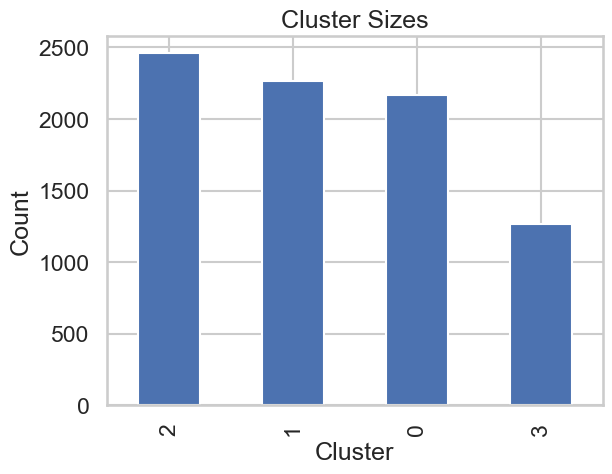

In [46]:
# 1. 确认两张表行数一致（保险起见）
print(len(df_raw), len(df_processed))

# 2. 把聚类结果加回原始完整数据
df_raw['cluster'] = df_processed['cluster'].values

df_raw['cluster'].value_counts().plot(kind='bar')
plt.title("Cluster Sizes")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()


## 7. Cluster Validity and Model Quality

### 7.1 Silhouette Score

In [144]:
import gower
from sklearn.metrics import silhouette_score

# 计算 Gower 距离矩阵（去掉 cluster 列）
gower_dist = gower.gower_matrix(df_processed.drop(columns=['cluster']))

# silhouette score（metric='precomputed' 因为我们直接给距离矩阵）
sil_score = silhouette_score(gower_dist, df_processed['cluster'],
                             metric='precomputed')
print("Silhouette Score:", sil_score)

Silhouette Score: 0.075912684


In [145]:
# 1. 类内方差（数值变量）
intra_var = df_processed.groupby("cluster")[numeric_features].var()
print("Intra-cluster variance:")
print(intra_var)

# 2. 类之间 prototype（centroids）
prototypes = kproto_final.cluster_centroids_
print("Cluster centroids:")
print(prototypes)


Intra-cluster variance:
              age  income_poverty_ratio       bmi       sbp       dbp  \
cluster                                                                 
0        0.294453              0.517300  0.594065  0.638280  0.582088   
1        0.426346              0.601847  0.900614  0.346528  0.537153   
2        0.680614              0.293532  0.587659  0.468653  0.549163   
3        0.534743              0.904916  1.900174  1.349725  1.069494   

              a1c  sleep_hours  household_size  
cluster                                         
0        0.817507     1.194520        0.396888  
1        0.185859     0.986027        1.084883  
2        0.240372     0.630584        0.445144  
3        3.215593     1.196802        0.841527  
Cluster centroids:
[['0.8730199986532764' '-0.5121074944034377' '-0.08736015493669068'
  '0.14443545578544234' '-0.3121015096052984' '0.20646308518700207'
  '0.2665377527818011' '-0.5407949408788704' 'Female'
  'Non-Hispanic White' 'High schoo

## 8. Cluster Profiles

To understand the characteristics of each cluster, we computed demographic,
health, lifestyle, and insurance-related summaries.  
These profiles help clarify what distinguishes each subgroup and how they
relate to hypertension risk and healthcare access.


### 8.1 Hypertension Severity

This section evaluates hypertension severity across clusters using three complementary measures:

**1. Mean SBP/DBP**: Higher averages indicate elevated overall blood pressure risk.

**2. Percent of Stage 1 & Stage 2 Hypertension**: Proportion of individuals meeting clinical thresholds.

**3. Distribution of Hypertension Stages**: Normal / Stage 1 / Stage 2.

Together, these indicators identify clusters with heightened cardiovascular risk requiring greater monitoring or targeted public-health interventions.

In [95]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(
    style="whitegrid",
    font_scale=1.2,
    rc={
        "figure.figsize": (8,5),
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12
    }
)


#### Hypertension Stage Classification

We first classify each individual into:

- Normal

- Stage 1 Hypertension: SBP ≥ 130 or DBP ≥ 80

- Stage 2 Hypertension: SBP ≥ 140 or DBP ≥ 90

A numeric version (0/1/2) is also created for calculating proportions.

In [79]:
# ----- Add hypertension stage classification -----
def classify_hypertension_stage(row):
    sbp = row['sbp']
    dbp = row['dbp']

    if pd.isna(sbp) or pd.isna(dbp):
        return None  

    if sbp >= 140 or dbp >= 90:
        return "Stage 2"
    elif sbp >= 130 or dbp >= 80:
        return "Stage 1"
    else:
        return "Normal"

df_raw['htn_stage'] = df_raw.apply(classify_hypertension_stage, axis=1)

mapping = {"Normal": 0, "Stage 1": 1, "Stage 2": 2}
df_raw["htn_stage_num"] = df_raw["htn_stage"].map(mapping)

#### 8.1.1 Cluster-Level Hypertension Profile
This table summarizes the mean SBP/DBP and the percentage of individuals in Stage 1 or Stage 2 Hypertension for each cluster.

Higher values—particularly high Stage 2 percentages—indicate clusters with more severe hypertension risk.

In [80]:
htn_profile = (
    df_raw.groupby("cluster")
    .agg(
        mean_sbp=("sbp", "mean"),
        mean_dbp=("dbp", "mean"),
        stage2_htn_pct=("htn_stage_num", lambda x: (x >= 2).mean() * 100),
        stage1_htn_pct=("htn_stage_num", lambda x: (x == 1).mean() * 100)
    )
)

htn_profile

,mean_sbp,mean_dbp,stage2_htn_pct,stage1_htn_pct
cluster,,,,
0,124.329488,71.598523,10.152284,17.628057
1,111.174834,70.727373,0.971302,9.624724
2,119.036208,74.076078,5.044752,20.260374
3,142.870150,88.509897,67.300079,24.623911


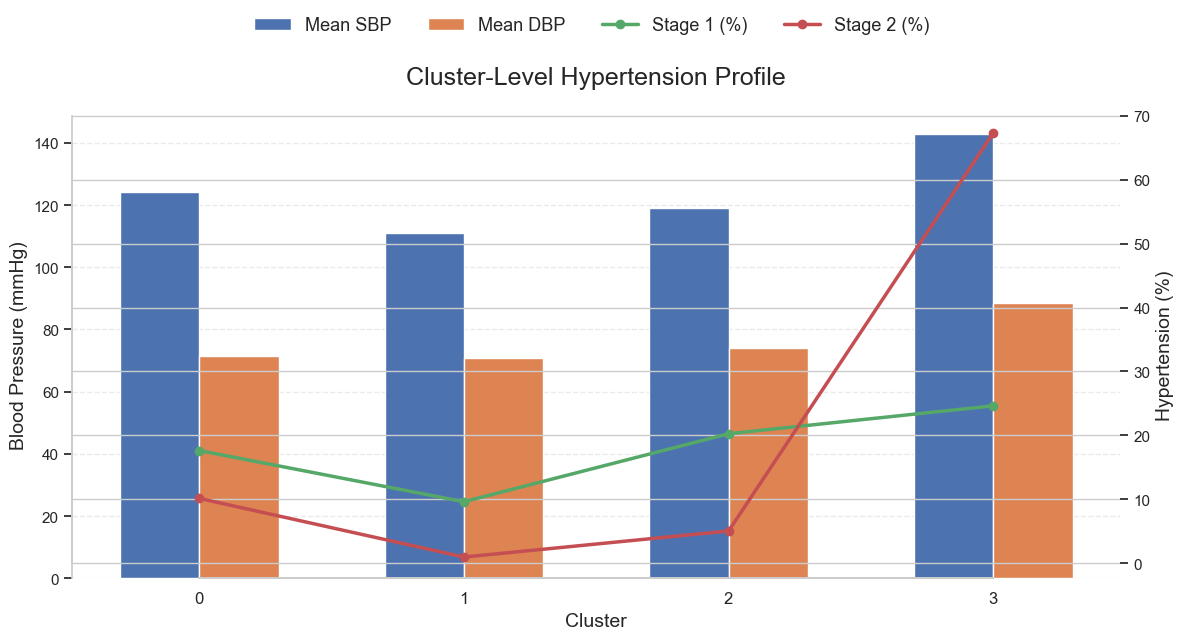

In [119]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Use Nature-style colors (muted, elegant)
nature_colors = {
    "sbp": "#4C72B0",      # muted blue
    "dbp": "#DD8452",      # muted orange
    "stage1": "#55A868",   # muted green
    "stage2": "#C44E52",   # muted red
}

sns.set_theme(style="whitegrid")

clusters = htn_profile.index.astype(str)
x = np.arange(len(clusters))
width = 0.30

fig, ax1 = plt.subplots(figsize=(12, 6))

# --- Bar plots (SBP / DBP) ---
ax1.bar(x - width/2, htn_profile["mean_sbp"], 
        width, label="Mean SBP", color=nature_colors["sbp"])
ax1.bar(x + width/2, htn_profile["mean_dbp"], 
        width, label="Mean DBP", color=nature_colors["dbp"])

ax1.set_ylabel("Blood Pressure (mmHg)", fontsize=14)
ax1.set_xlabel("Cluster", fontsize=14)
ax1.set_xticks(x)
ax1.set_xticklabels(clusters, fontsize=12)

# Light, elegant grid like Nature journals
ax1.grid(True, which='major', axis='y', linestyle='--', alpha=0.4)
ax1.grid(False, axis='x')

# --- Line plots (Stage %) ---
ax2 = ax1.twinx()

ax2.plot(x, htn_profile["stage1_htn_pct"], 
        marker="o", linewidth=2.5, color=nature_colors["stage1"], label="Stage 1 (%)")
ax2.plot(x, htn_profile["stage2_htn_pct"], 
        marker="o", linewidth=2.5, color=nature_colors["stage2"], label="Stage 2 (%)")

ax2.set_ylabel("Hypertension (%)", fontsize=14)

# --- Legend styling (Nature-style minimalism) ---
# Merge legends from both axes
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

fig.legend(handles1 + handles2, labels1 + labels2,
           loc="upper center", bbox_to_anchor=(0.5, 1.08),
           ncol=4, frameon=False, fontsize=13)

plt.title("Cluster-Level Hypertension Profile", fontsize=18, pad=20)
sns.despine(trim=True)  # Remove top and right borders for Nature style

plt.tight_layout()
plt.show()


#### 8.1.2 Distribution of Hypertension Stages
To complement the severity profile, we show the proportion of individuals in each hypertension stage within each cluster:

In [81]:
htn_stage_table = pd.crosstab(
    df_raw['cluster'],
    df_raw['htn_stage'],
    normalize='index'
).round(3)

htn_stage_table


htn_stage,Normal,Stage 1,Stage 2
cluster,,,
0,0.722,0.176,0.102
1,0.894,0.096,0.010
2,0.747,0.203,0.050
3,0.081,0.246,0.673


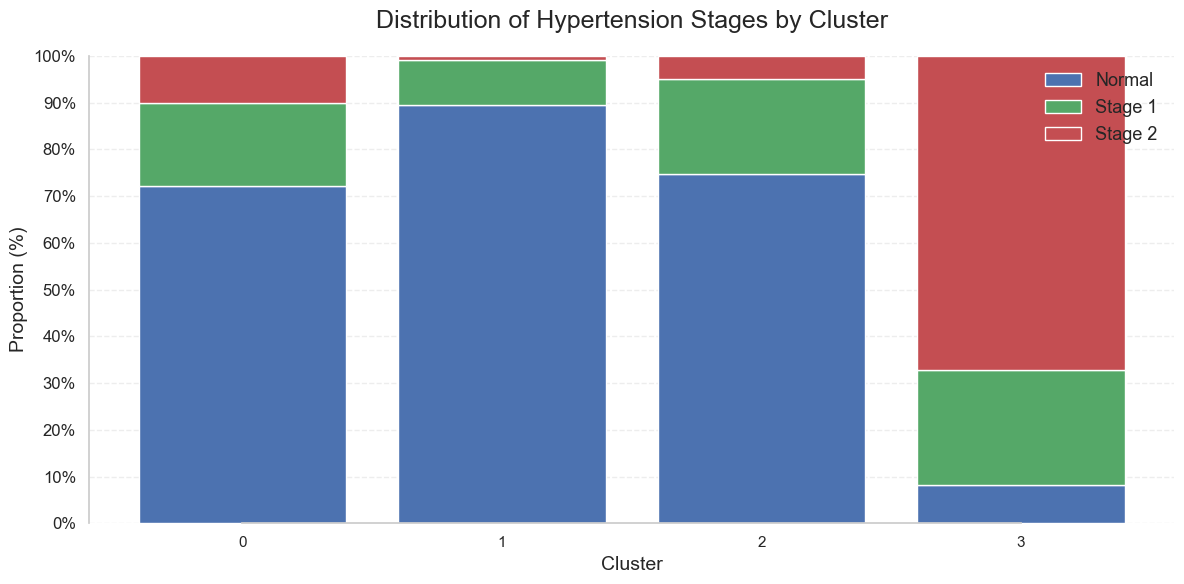

In [120]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Nature muted palette
nature_colors = {
    "Normal":  "#4C72B0",   # muted blue
    "Stage 1": "#55A868",   # muted green
    "Stage 2": "#C44E52",   # muted red
}

sns.set_theme(style="whitegrid")

# Extract table in correct cluster order
clusters = htn_stage_table.index.astype(str)
normal = htn_stage_table["Normal"]
stage1 = htn_stage_table["Stage 1"]
stage2 = htn_stage_table["Stage 2"]

# Convert proportions to %
normal_pct = normal * 100
stage1_pct = stage1 * 100
stage2_pct = stage2 * 100

fig, ax = plt.subplots(figsize=(12, 6))

# --- Stacked Bars ---
ax.bar(clusters, normal_pct, 
       color=nature_colors["Normal"], label="Normal")
ax.bar(clusters, stage1_pct, bottom=normal_pct, 
       color=nature_colors["Stage 1"], label="Stage 1")
ax.bar(clusters, stage2_pct, bottom=normal_pct + stage1_pct,
       color=nature_colors["Stage 2"], label="Stage 2")

# Labels
ax.set_ylabel("Proportion (%)", fontsize=14)
ax.set_xlabel("Cluster", fontsize=14)

# Clean Nature-style grid
ax.grid(True, axis='y', linestyle='--', alpha=0.35)
ax.grid(False, axis='x')

# Y-axis in %
ax.set_ylim(0, 100)
ax.set_yticks(np.arange(0, 101, 10))
ax.set_yticklabels([f"{i}%" for i in range(0, 101, 10)], fontsize=12)

# Title
plt.title("Distribution of Hypertension Stages by Cluster", fontsize=18, pad=20)

# Legend — small, floating, no border (Nature style)
legend = plt.legend(frameon=False, fontsize=13, loc="upper right")

# Nature-style despine
sns.despine(trim=True)

plt.tight_layout()
plt.show()


### 8.2 Insurance Coverage Patterns

Insurance access significantly affects hypertension diagnosis, treatment,
and long-term health outcomes.

This table reports the distribution of insurance types within each cluster,
revealing whether high-risk groups have adequate healthcare access.


In [70]:
insurance_profile = (
    df_raw.groupby("cluster")["insurance_type"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("percent")
    .reset_index()
)

insurance_wide = (
    insurance_profile
    .pivot(index="cluster", columns="insurance_type", values="percent")
    .fillna(0)
    .round(2)
)

insurance_wide


insurance_type,Both,Private only,Public only,Uninsured,Unknown
cluster,,,,,
0,28.56,7.75,57.22,5.58,0.88
1,2.43,37.75,40.13,16.25,3.44
2,15.50,62.08,17.53,4.19,0.69
3,17.97,29.37,42.91,9.11,0.63


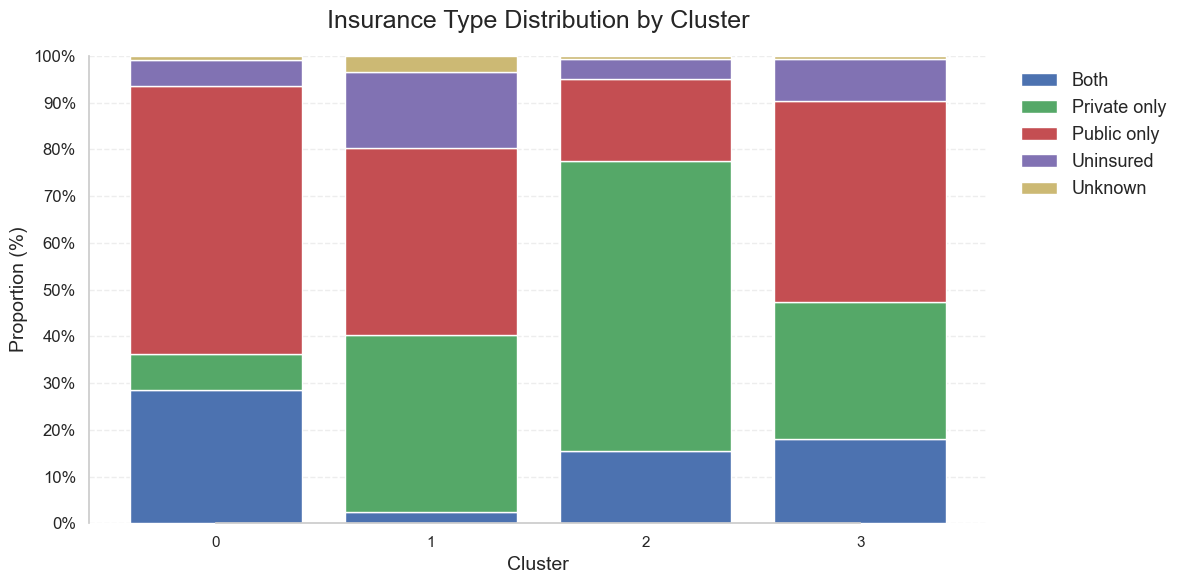

In [121]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Nature muted earth-tone palette ---
nature_insurance_colors = {
    "Both":         "#4C72B0",  # muted blue
    "Private only": "#55A868",  # muted green
    "Public only":  "#C44E52",  # muted red
    "Uninsured":    "#8172B3",  # muted purple
    "Unknown":      "#CCB974",  # muted yellow/brown
}

sns.set_theme(style="whitegrid")

df_plot = insurance_wide.copy()
clusters = df_plot.index.astype(str)

# Prepare percentage matrix
bottom = np.zeros(len(df_plot))

fig, ax = plt.subplots(figsize=(12, 6))

for col in df_plot.columns:
    values = df_plot[col]
    ax.bar(
        clusters,
        values,
        bottom=bottom,
        label=col,
        color=nature_insurance_colors[col],
        edgecolor="white"
    )
    bottom += values

# Labels
ax.set_ylabel("Proportion (%)", fontsize=14)
ax.set_xlabel("Cluster", fontsize=14)
plt.title("Insurance Type Distribution by Cluster", fontsize=18, pad=20)

# Y axis formatting
ax.set_ylim(0, 100)
ax.set_yticks(np.arange(0, 101, 10))
ax.set_yticklabels([f"{i}%" for i in range(0, 101, 10)], fontsize=12)

# Grid
ax.grid(True, axis='y', linestyle='--', alpha=0.35)
ax.grid(False, axis='x')

# Legend — Nature style: small, borderless, upper right
plt.legend(frameon=False, fontsize=13, bbox_to_anchor=(1.02, 1), loc="upper left")

# Nature-style despine
sns.despine(trim=True)

plt.tight_layout()
plt.show()


### 8.3 Socioeconomic Status (SES) Profile

We summarize SES characteristics using both numeric and categorical indicators.
Numeric SES variables (income-to-poverty ratio, household size) are summarized using
cluster-wise means, while categorical SES variables (education, employment, marital status)
are summarized using within-cluster proportions.

This separation avoids incorrect assumptions of numeric structure for categorical SES features
and provides a clearer, more interpretable SES profile per cluster.


In [72]:
ses_numeric = (
    df_raw.groupby("cluster")
    .agg({
        "income_poverty_ratio": "mean",
        "household_size": "mean",
    })
    .round(2)
)

ses_edu = (
    df_raw.groupby("cluster")["education"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("pct")
    .reset_index()
    .pivot(index="cluster", columns="education", values="pct")
    .fillna(0)
    .round(2)
)

ses_emp = (
    df_raw.groupby("cluster")["is_employed"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("pct")
    .reset_index()
    .pivot(index="cluster", columns="is_employed", values="pct")
    .fillna(0)
    .round(2)
)

ses_marital = (
    df_raw.groupby("cluster")["marital_status"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("pct")
    .reset_index()
    .pivot(index="cluster", columns="marital_status", values="pct")
    .fillna(0)
    .round(2)
)

from IPython.display import display

display(ses_numeric)
display(ses_edu)
display(ses_emp)
display(ses_marital)

,income_poverty_ratio,household_size
cluster,,
0,2.07,1.82
1,2.03,3.95
2,4.41,2.17
3,2.64,2.51


education,9-11th grade,<9th grade,College graduate or above,High school/GED,Some college/AA,Unknown
cluster,,,,,,
0,12.51,8.08,18.23,30.73,30.00,0.46
1,9.05,3.93,20.35,21.63,30.29,14.75
2,2.24,1.14,60.50,11.88,23.39,0.85
3,10.69,6.41,22.33,23.83,36.34,0.40


is_employed,No,Yes
cluster,,
0,82.74,17.26
1,34.92,65.08
2,30.11,69.89
3,56.29,43.71


marital_status,Married / living with partner,Never married,Unknown,Widowed / divorced / separated
cluster,,,,
0,38.39,14.03,0.37,47.21
1,46.05,29.01,14.75,10.20
2,63.63,19.04,0.90,16.44
3,55.19,15.52,0.48,28.82


/var/folders/f2/ms2jwb5x6ml5ggd3pv6bzx2m0000gn/T/ipykernel_21626/32128836.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


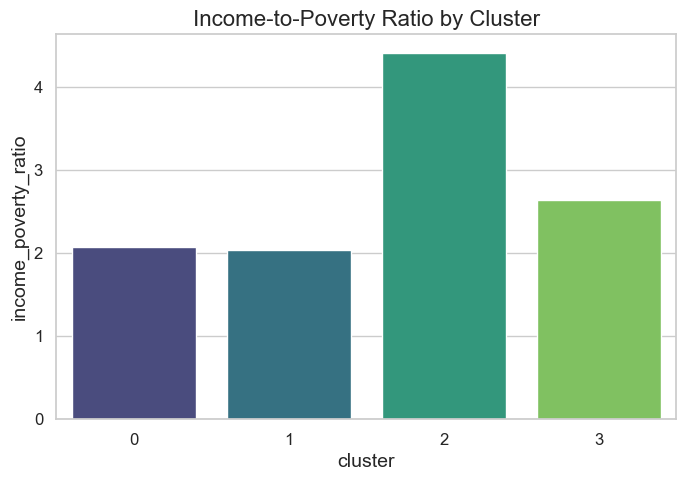

In [102]:
sns.barplot(
    data=ses_numeric.reset_index(),
    x="cluster", y="income_poverty_ratio", palette="viridis"
)
plt.title("Income-to-Poverty Ratio by Cluster")
plt.show()

/var/folders/f2/ms2jwb5x6ml5ggd3pv6bzx2m0000gn/T/ipykernel_21626/3643314958.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


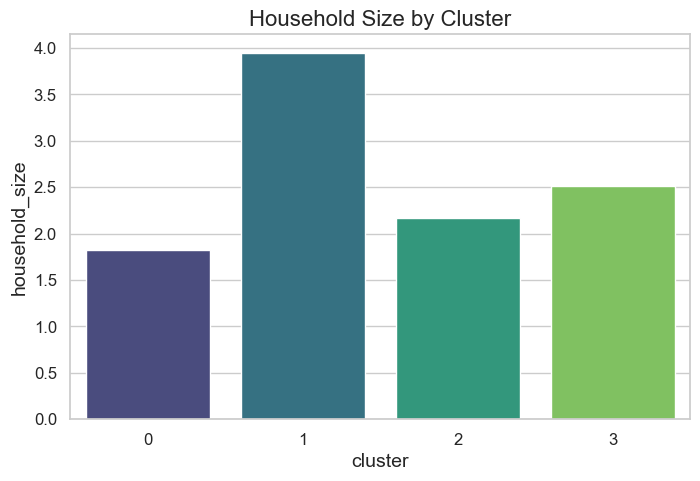

In [101]:
sns.barplot(
    data=ses_numeric.reset_index(),
    x="cluster", y="household_size", palette="viridis"
)
plt.title("Household Size by Cluster")
plt.show()

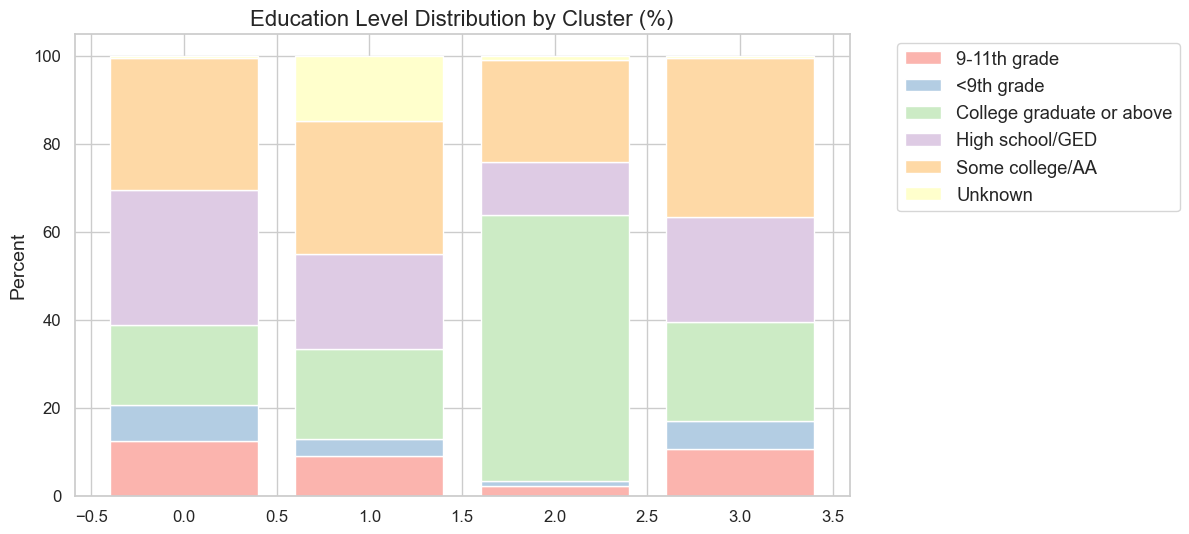

In [103]:
edu_plot = ses_edu.copy()

fig, ax = plt.subplots(figsize=(10,6))
bottom=None

colors = sns.color_palette("Pastel1", edu_plot.shape[1])

for i, col in enumerate(edu_plot.columns):
    ax.bar(
        edu_plot.index, edu_plot[col],
        bottom=bottom, color=colors[i], label=col
    )
    bottom = edu_plot[col] if bottom is None else bottom + edu_plot[col]

plt.title("Education Level Distribution by Cluster (%)")
plt.ylabel("Percent")
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")
plt.show()


/var/folders/f2/ms2jwb5x6ml5ggd3pv6bzx2m0000gn/T/ipykernel_21626/931367598.py:45: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.swarmplot(
/opt/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 14.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 10.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 55.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: U

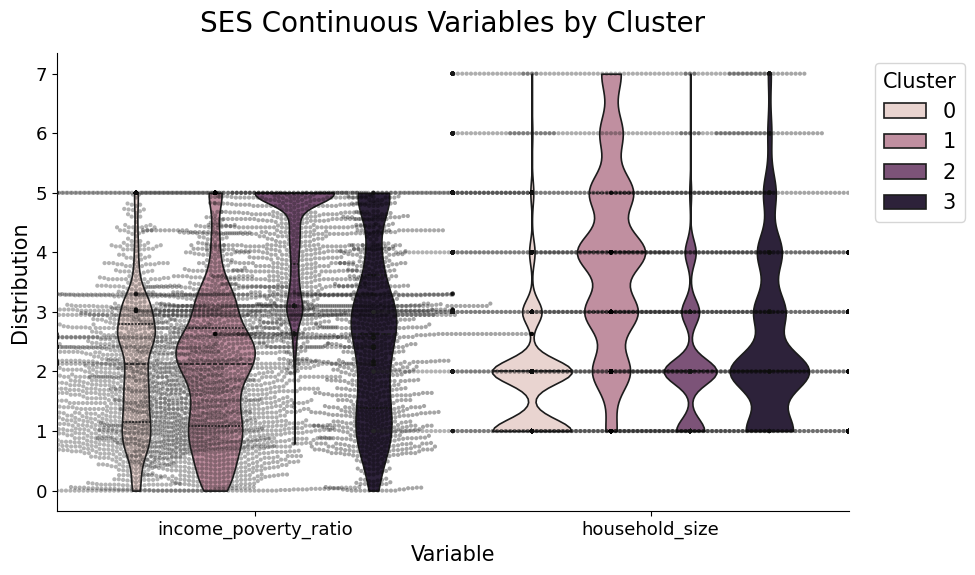

In [133]:
# Step 1: Prepare numeric SES data using RAW dataset
numeric_vars = ["income_poverty_ratio", "household_size"]

ses_numeric_raw = df_raw[["cluster"] + numeric_vars]

ses_numeric_long = ses_numeric_raw.melt(
    id_vars="cluster",
    value_vars=numeric_vars,
    var_name="variable",
    value_name="value"
)
def set_nature_style():
    plt.style.use("default")  # avoid missing style errors

    # Nature palette (greenish + orange)
    sns.set_palette(["#4C9F70", "#E17C05", "#5D3A9B", "#C44536"])

    plt.rcParams.update({
        "font.size": 15,
        "axes.titlesize": 20,
        "axes.labelsize": 15,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "grid.color": "#DDDDDD",
        "grid.linestyle": "--",
        "grid.linewidth": 0.5,
    })
set_nature_style()

fig, ax = plt.subplots(figsize=(10, 6))

sns.violinplot(
    data=ses_numeric_long,
    x="variable",
    y="value",
    hue="cluster",
    inner="quartile",
    cut=0,
    linewidth=1.2,
    ax=ax
)

sns.swarmplot(
    data=ses_numeric_long,
    x="variable",
    y="value",
    hue="cluster",
    dodge=True,
    color="black",
    alpha=0.35,
    size=3,
    ax=ax
)

# Fix legend (avoid duplicates)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:4], labels[:4], title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")

ax.set_title("SES Continuous Variables by Cluster", pad=15)
ax.set_xlabel("Variable")
ax.set_ylabel("Distribution")

plt.tight_layout()
plt.show()


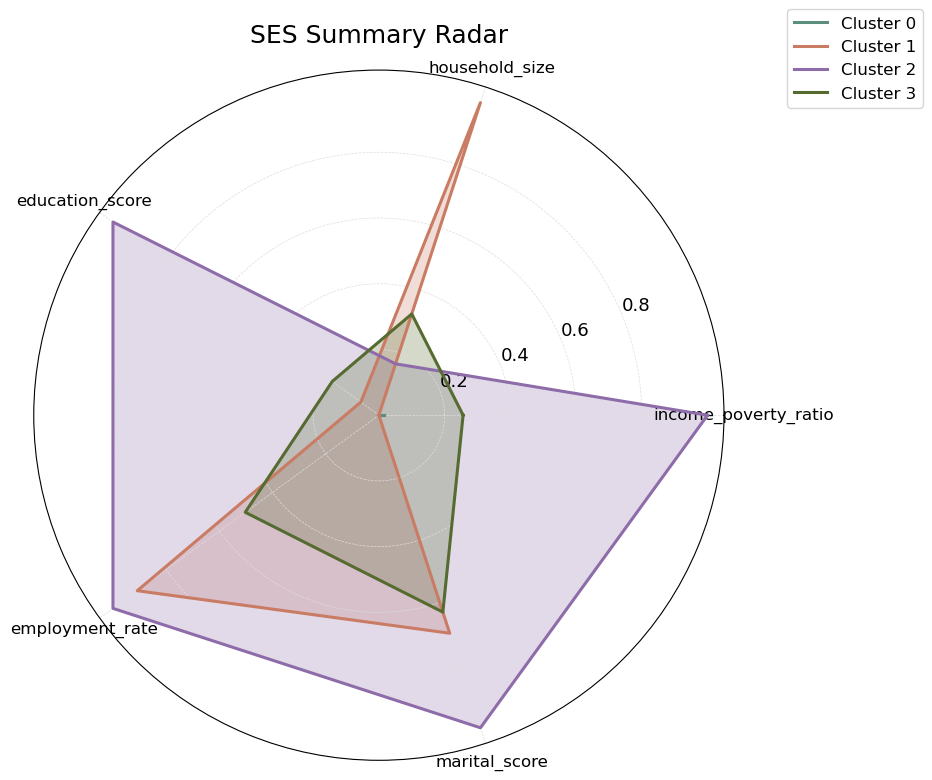

In [138]:
# ==== Build SES Radar Indicators ====

ses_radar = pd.DataFrame(index=ses_numeric.index)

# 1. numeric
ses_radar["income_poverty_ratio"] = ses_numeric["income_poverty_ratio"]
ses_radar["household_size"]       = ses_numeric["household_size"]

# 2. Education SES score
# ---- 2. Education SES score ----
# Add missing category "Unknown"
edu_weights = {
    "<9th grade": 0.2,
    "9-11th grade": 0.3,
    "High school/GED": 0.5,
    "Some college/AA": 0.7,
    "College graduate or above": 1.0,
    "Unknown": 0.4
}

ses_radar["education_score"] = (
    ses_edu.mul([edu_weights[c] for c in ses_edu.columns], axis=1)
           .sum(axis=1) / 100
)


# 3. Employment rate (% Yes)
ses_radar["employment_rate"] = ses_emp["Yes"] / 100

# 4. Marital stability score
marital_weights = {
    "Married / living with partner": 1.0,
    "Never married": 0.5,
    "Widowed / divorced / separated": 0.0,
    "Unknown": 0.3
}
ses_radar["marital_score"] = (
    ses_marital.mul([marital_weights[c] for c in ses_marital.columns], axis=1)
               .sum(axis=1) / 100
)

ses_radar
import numpy as np
import matplotlib.pyplot as plt

# Normalize
ses_norm = (ses_radar - ses_radar.min()) / (ses_radar.max() - ses_radar.min())
labels = ses_radar.columns.tolist()
num_vars = len(labels)

angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

colors = ["#5B8E7D", "#C97B63", "#8E6CAA", "#556B2F"]

plt.figure(figsize=(10,8))
ax = plt.subplot(111, polar=True)

for i, (cluster, row) in enumerate(ses_norm.iterrows()):
    values = row.tolist() + [row.tolist()[0]]
    ax.plot(angles, values, color=colors[i], linewidth=2.2, label=f"Cluster {cluster}")
    ax.fill(angles, values, color=colors[i], alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=12)

ax.set_yticks([0.2,0.4,0.6,0.8])
ax.set_yticklabels(["0.2","0.4","0.6","0.8"])

ax.set_title("SES Summary Radar", fontsize=18, pad=20)
plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=12)
plt.tight_layout()
plt.show()


### 8.4 Demographic Profile

In [73]:
demographic_profile = (
    df_raw.groupby("cluster")
    .agg({
        "age": "mean",
        "gender": lambda x: (x == "Male").mean() * 100,
        "race": lambda x: x.value_counts(normalize=True).idxmax(),
    })
)
demographic_profile


,age,gender,race
cluster,,,
0,68.340563,41.716659,Non-Hispanic White
1,33.029581,36.158940,Non-Hispanic White
2,52.231082,55.451587,Non-Hispanic White
3,58.466350,45.209818,Non-Hispanic White


/var/folders/f2/ms2jwb5x6ml5ggd3pv6bzx2m0000gn/T/ipykernel_21626/1033781802.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


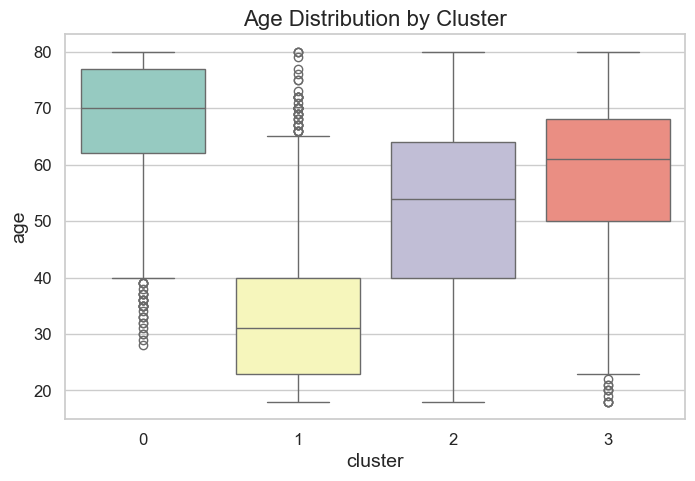

In [104]:
sns.boxplot(
    data=df_raw, x="cluster", y="age", palette="Set3"
)
plt.title("Age Distribution by Cluster")
plt.show()


### 8.5 Behavioral & Lifestyle Profile
This section summarizes behavior-related health determinants across clusters,
including BMI, sleep patterns, and smoking prevalence.


In [76]:
lifestyle_numeric = (
    df_raw.groupby("cluster")
    .agg({
        "bmi": "mean",
        "sleep_hours": "mean",
    })
    .round(2)
)

lifestyle_smoking = (
    df_raw.groupby("cluster")["smoking_current"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("pct")
    .reset_index()
    .pivot(index="cluster", columns="smoking_current", values="pct")
    .fillna(0)
    .round(2)
)

from IPython.display import display

display(lifestyle_numeric)
display(lifestyle_smoking)


,bmi,sleep_hours
cluster,,
0,28.75,8.17
1,28.05,7.78
2,28.29,7.40
3,34.58,7.60


smoking_current,Don't know,No,Refused,Unknown,Yes
cluster,,,,,
0,0.09,39.69,0.14,0.14,59.94
1,0.22,72.05,0.00,0.49,27.24
2,0.00,67.98,0.16,0.16,31.69
3,0.00,56.61,0.00,0.00,43.39


/var/folders/f2/ms2jwb5x6ml5ggd3pv6bzx2m0000gn/T/ipykernel_21626/4049974190.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


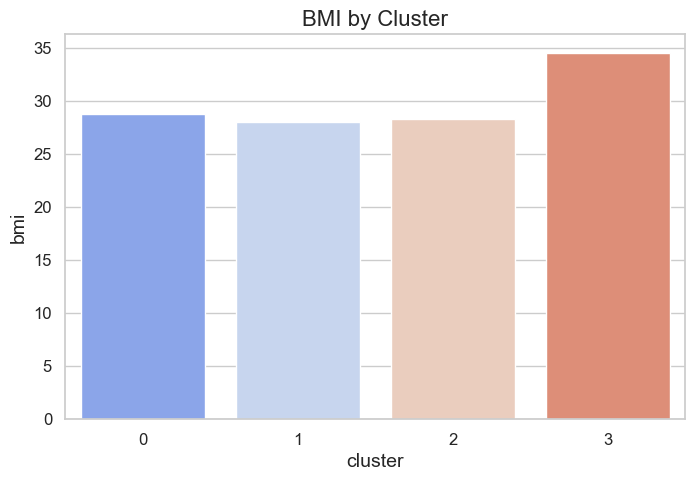

In [105]:
sns.barplot(
    data=lifestyle_numeric.reset_index(),
    x="cluster", y="bmi", palette="coolwarm"
)
plt.title("BMI by Cluster")
plt.show()


/var/folders/f2/ms2jwb5x6ml5ggd3pv6bzx2m0000gn/T/ipykernel_21626/3484330719.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


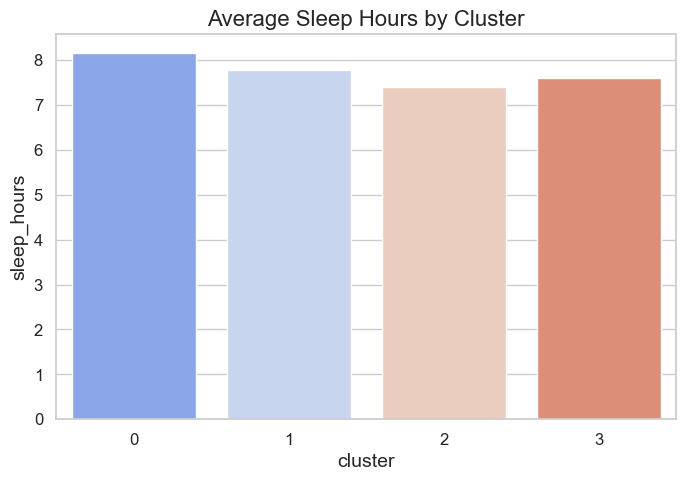

In [106]:
sns.barplot(
    data=lifestyle_numeric.reset_index(),
    x="cluster", y="sleep_hours", palette="coolwarm"
)
plt.title("Average Sleep Hours by Cluster")
plt.show()


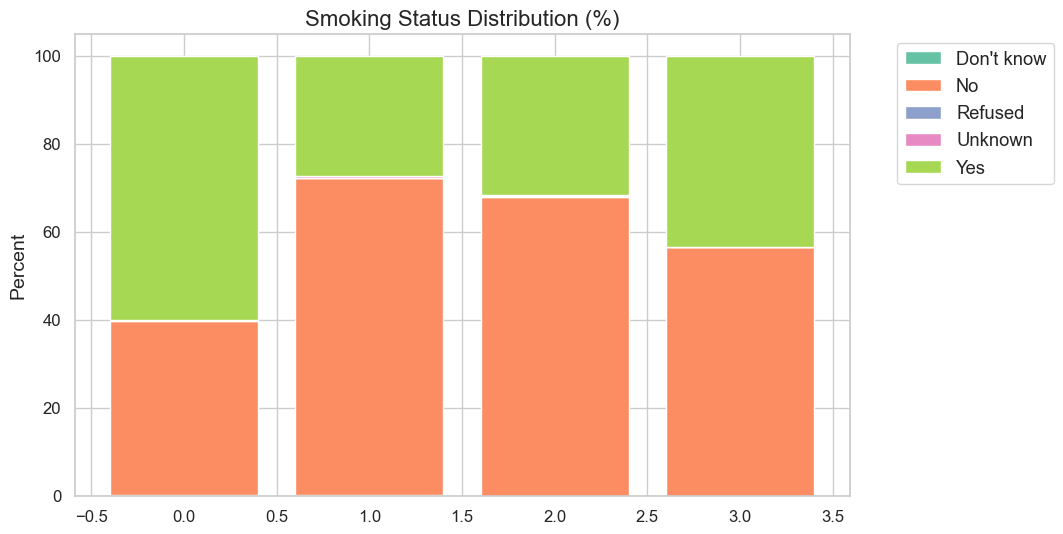

In [107]:
smoke_plot = lifestyle_smoking.copy()

fig, ax = plt.subplots(figsize=(10,6))
bottom=None

colors = sns.color_palette("Set2", smoke_plot.shape[1])

for i, col in enumerate(smoke_plot.columns):
    ax.bar(
        smoke_plot.index, smoke_plot[col],
        bottom=bottom, color=colors[i], label=col
    )
    bottom = smoke_plot[col] if bottom is None else bottom + smoke_plot[col]

plt.title("Smoking Status Distribution (%)")
plt.ylabel("Percent")
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")
plt.show()


### 8.6 Diabetes Status Distribution
To further characterize health outcomes across clusters, we examine the distribution of self-reported diabetes status (Yes / No / Borderline).

In [109]:
# 如果 diabetes_self_report 是 Yes / No
diabetes_table = pd.crosstab(
    df_raw['cluster'],
    df_raw['diabetes_self_report'],
    normalize='index'
).round(3)
diabetes_table

diabetes_self_report,Borderline,Don't know,No,Unknown,Yes
cluster,,,,,
0,0.046,0.0,0.734,0.0,0.219
1,0.016,0.0,0.950,0.0,0.034
2,0.028,0.0,0.900,0.0,0.071
3,0.053,0.0,0.671,0.0,0.276


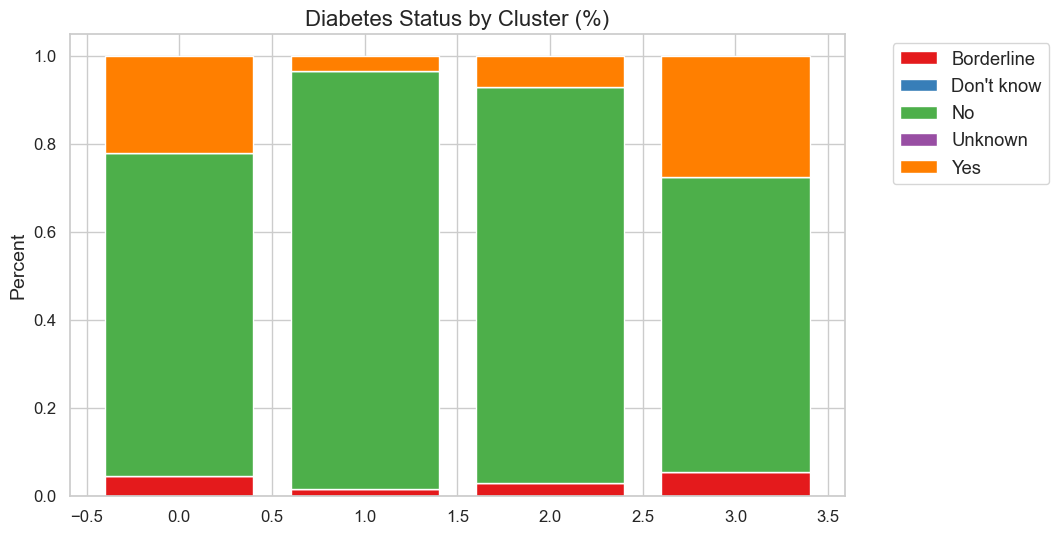

In [110]:
diab = diabetes_table.copy()

fig, ax = plt.subplots(figsize=(10,6))
bottom = None
colors = sns.color_palette("Set1", diab.shape[1])

for i, col in enumerate(diab.columns):
    ax.bar(
        diab.index, diab[col],
        bottom=bottom, color=colors[i], label=col
    )
    bottom = diab[col] if bottom is None else bottom + diab[col]

plt.title("Diabetes Status by Cluster (%)")
plt.ylabel("Percent")
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")
plt.show()


### 8.7 Lifestyle–Risk Interaction
To explore whether lifestyle behaviors align with physiological risk across clusters, we summarize key lifestyle indicators alongside major risk biomarkers.
This allows us to identify patterns such as:

- clusters with higher SBP/DBP but also higher smoking prevalence,

- or clusters with healthier sleep patterns and lower metabolic risk.

In [93]:
# 统一列名后的 smoking_pct
smoking_pct = (
    df_raw.groupby("cluster")["smoking_current"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("percent")
    .reset_index()
    .pivot(index="cluster", columns="smoking_current", values="percent")
    .fillna(0)
    .round(2)
).rename(columns={
    "Yes": "smoking_yes_pct",
    "No": "smoking_no_pct",
    "Don't know": "smoking_dontknow_pct",
    "Refused": "smoking_refused_pct",
    "Unknown": "smoking_unknown_pct",
})

sleep_profile = (
    df_raw.groupby("cluster")["sleep_hours"]
    .mean()
    .round(2)
    .to_frame(name="sleep_hours")
)

interaction_table = (
    risk_profile
    .join(smoking_pct, how="left")
    .join(sleep_profile, how="left")
)

interaction_table


,sbp,dbp,bmi,a1c,smoking_dontknow_pct,smoking_no_pct,smoking_refused_pct,smoking_unknown_pct,smoking_yes_pct,sleep_hours
cluster,,,,,,,,,,
0,124.33,71.60,28.75,5.89,0.09,39.69,0.14,0.14,59.94,8.17
1,111.17,70.73,28.05,5.32,0.22,72.05,0.00,0.49,27.24,7.78
2,119.04,74.08,28.29,5.49,0.00,67.98,0.16,0.16,31.69,7.40
3,142.87,88.51,34.58,6.43,0.00,56.61,0.00,0.00,43.39,7.60


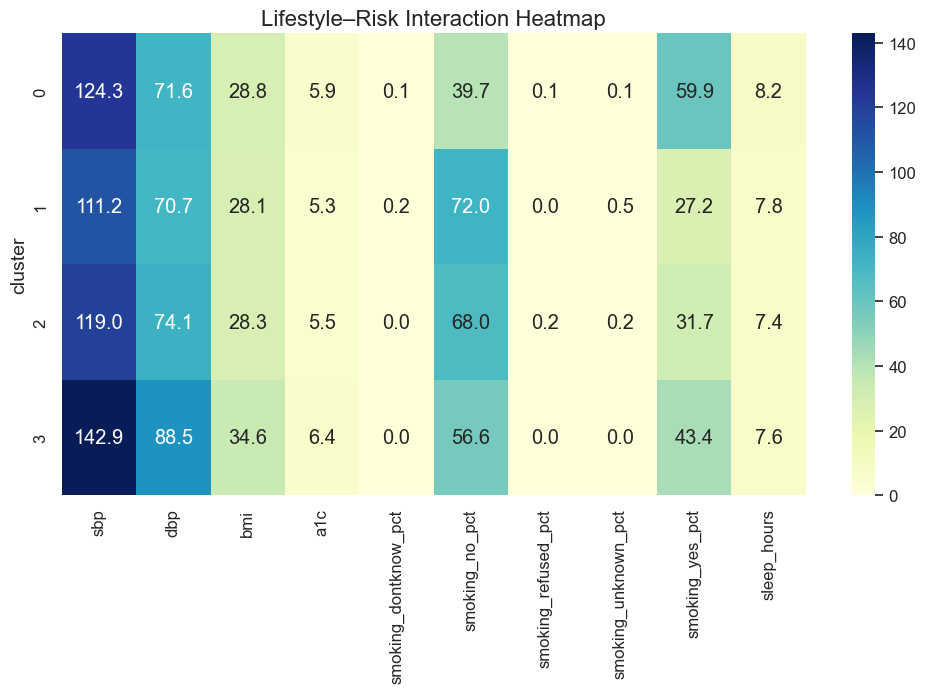

In [112]:
heatmap_data = interaction_table.copy()

plt.figure(figsize=(12,6))
sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="YlGnBu",
    fmt=".1f"
)
plt.title("Lifestyle–Risk Interaction Heatmap")
plt.show()


<Figure size 960x600 with 0 Axes>

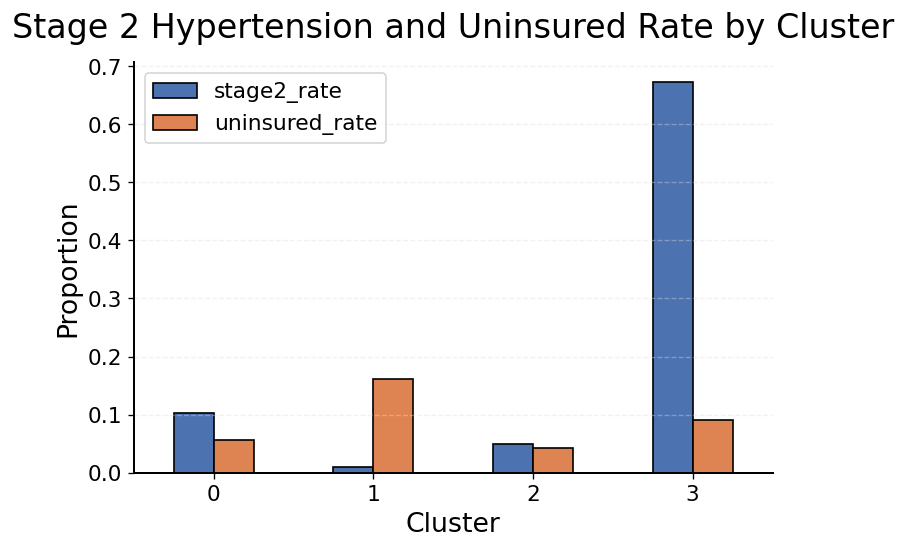

In [142]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Nature-style settings ---
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 20,
    "axes.labelsize": 16,
    "axes.linewidth": 1.2,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.dpi": 120,
    "grid.linewidth": 0.8
})

# Nature-like color palette
colors = ["#4C72B0", "#DD8452"]   # Blue / Orange (Nature 常用配色)

plt.figure(figsize=(8, 5))

risk_table[["stage2_rate", "uninsured_rate"]].plot(
    kind="bar",
    color=colors,
    edgecolor="black",
    linewidth=1.0
)

plt.title("Stage 2 Hypertension and Uninsured Rate by Cluster", pad=15)
plt.ylabel("Proportion")
plt.xlabel("Cluster")

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

# 保存文件
plt.savefig(
    os.path.join(save_dir, "cluster_htn_uninsured_bar_nature.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 9. Interpretation and Public Health Implications

### Cluster 0 — Moderate HTN, mostly public insured
This group shows moderately elevated SBP/DBP and the highest proportion of public insurance.
The pattern suggests socioeconomic constraints and possible delays in receiving preventive care.
They may benefit from community-based hypertension monitoring programs and improved access to
primary care services.

### Cluster 1 — Low-risk, mixed public/private & more uninsured
This is the healthiest cluster, with the lowest hypertension prevalence.
The higher uninsured percentage aligns with a younger and generally healthier demographic.
Although low-risk, the lack of insurance may lead to inadequate screening and delayed diagnosis
in the future.

### Cluster 2 — Mild HTN, mainly privately insured
Individuals in this cluster have mild hypertension but strong private insurance coverage.
They represent a stable socioeconomic group with better access to diagnosis and preventive
care services. Lifestyle interventions may help prevent progression to severe hypertension.

### Cluster 3 — Severe HTN, mixed insurance coverage
This cluster displays significantly elevated blood pressure and the highest concentration
of Stage 2 hypertension. Mixed insurance patterns indicate inconsistent access to medical care.
This group warrants immediate attention—targeted interventions, increased screening, and
access to antihypertensive treatment are essential for reducing long-term cardiovascular risks.

### Overall Implications
These four clusters highlight how hypertension risk is intertwined with insurance coverage,
socioeconomic status, and lifestyle patterns. Identifying high-risk and underinsured
groups provides actionable insights for public health policy, community interventions,
and health equity efforts.


## 10. Limitations and Next Steps

### Limitations
- **Self-reported variables** (smoking, alcohol, physical activity) may introduce recall bias.
- **Cross-sectional dataset** limits causal inference.
- Insurance type was used only for profiling; incorporating more detailed healthcare utilization
data could strengthen interpretation.
- Clustering results are sensitive to feature scaling and categorical encoding.

### Next Steps
- Explore **K = 5 or 6** for finer-grained lifestyle-health patterns.
- Apply **cluster stability analysis** using bootstrapped samples.
- Validate clusters across demographic subgroups (age, gender, race).
- Integrate longitudinal outcomes (follow-up BP changes, medical visits) if available.


In [146]:
import numpy as np
import pandas as pd
from kmodes.kprototypes import KPrototypes
from sklearn.metrics import adjusted_rand_score
import matplotlib.pyplot as plt

# 1. 原始 clustering 结果（已训练好的模型）
original_labels = df_processed['cluster'].values

# 2. 要评估的重要度的特征列表
all_features = numeric_features + categorical_features

feature_importance = {}

for feat in all_features:
    df_temp = df_processed.copy()
    
    # 3. 随机打乱这个特征
    df_temp[feat] = np.random.permutation(df_temp[feat].values)
    
    # 4. 转成 numpy
    temp_matrix = df_temp.drop(columns=['cluster']).to_numpy()
    
    # 5. 重新 clustering（无需 n_init=5，用 1 即可）
    kproto_tmp = KPrototypes(
        n_clusters=best_k,
        init='Cao',
        n_init=1,
        verbose=0,
        random_state=42
    )
    tmp_labels = kproto_tmp.fit_predict(
        temp_matrix,
        categorical=[df_temp.columns.get_loc(c) for c in categorical_features]
    )
    
    # 6. 计算与原结果的差异（使用 ARI）
    ari = adjusted_rand_score(original_labels, tmp_labels)
    importance = 1 - ari   # ARI 越小 → importance 越高
    feature_importance[feat] = importance

# 转成 DataFrame
importance_df = (
    pd.DataFrame.from_dict(feature_importance, orient="index", columns=["importance"])
    .sort_values("importance", ascending=False)
)

importance_df


,importance
income_poverty_ratio,0.596366
age,0.575220
sleep_hours,0.566757
household_size,0.405862
dbp,0.333554
sbp,0.301622
bmi,0.247526
is_employed,0.218974
smoking_current,0.215977
education,0.212252


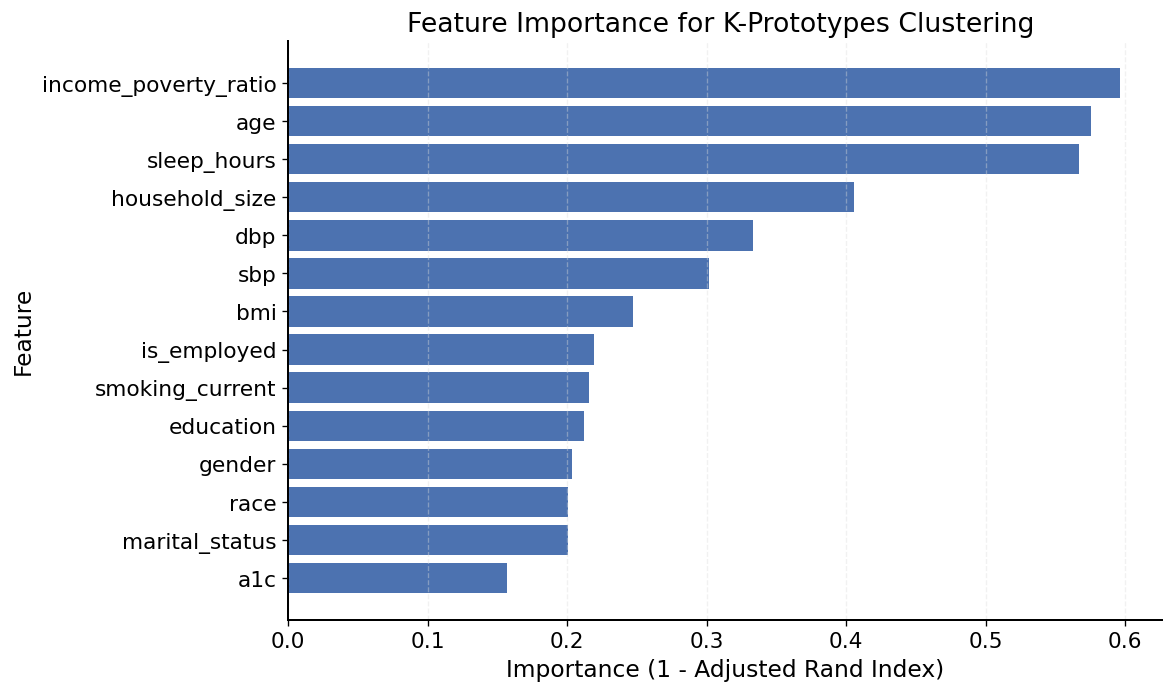

In [148]:
plt.figure(figsize=(10, 6))
plt.barh(
    importance_df.index,
    importance_df['importance'],
    color="#4C72B0"
)
plt.gca().invert_yaxis()

plt.title("Feature Importance for K-Prototypes Clustering ", 
          fontsize=16)
plt.xlabel("Importance (1 - Adjusted Rand Index)", fontsize=14)
plt.ylabel("Feature", fontsize=14)

plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
